In [1]:
import polars as pl
import numpy as np
from matplotlib import pyplot as plt

## Data format
The data is formatted as such:
Transverse moment ($p_{\text{T}1}$) of the first muon, the azimuth angle of the first muon ($\phi_1$), the
pseudo-rapidity of the first muon ($\eta_1$), transverse moment ($p_{\text{T}2}$) of the second muon, the
azimuth angle of the second muon ($\phi_2$), and the pseudo-rapidity of the second muon ($\eta_2$), the
effective mass of the dimuon system.

## Transformation of data
The cartesian momentum components of each muon can be calculated from the data provided.

$p_x = p_T \cos{\phi}$\
$p_y = p_T \sin{\phi}$\
$p_z = p_T \sinh{\eta}$\
$|p| = p_T \cosh{\eta}$

In [2]:
def perform_transformation(dataframe):
    """Performs a transformation to get the cartesian components and magnitude of the momentum and
    calculates the effective mass of the systems of dimuons from data which is in cylindrical coordinates.

    Args:
        dataframe (polars.DataFrame): a polars DataFrame of the format:
            transverse momentum 1, azimuth angle 1, pseudorapidity 1,
            transverse momentum 2, azimuth angle 2, pseudorapidity 2, effective mass

            with the column names:
            p_T1, phi_1, eta_1, p_T2, phi_2, eta_2, effective_mass

    Returns:
        polars.DataFrame: A polars DataFrame with columns specified below:
            p1_x, p1_z, p1_y, |p_1|, p2_x, p2_z, p2_y, |p_2|, calculated_effective_mass, effective_mass
    """
    p_t_1 = dataframe["p_T1"]
    p_t_2 = dataframe["p_T2"]
    phi_1 = dataframe["phi_1"]
    phi_2 = dataframe["phi_2"]
    eta_1 = dataframe["eta_1"]
    eta_2 = dataframe["eta_2"]

    p1_x = (p_t_1 * phi_1.cos()).alias("p1_x")
    p1_y = (p_t_1 * phi_1.sin()).alias("p1_y")
    p1_z = (p_t_1 * eta_1.sinh()).alias("p1_z")
    p1 = (p_t_1 * eta_1.cosh()).alias("|p1|")

    p2_x = (p_t_2 * phi_2.cos()).alias("p2_x")
    p2_y = (p_t_2 * phi_2.sin()).alias("p2_y")
    p2_z = (p_t_2 * eta_2.sinh()).alias("p2_z")
    p2 = (p_t_2 * eta_2.cosh()).alias("|p2|")

    # use approximation m_mu is negligible compared to momentum, E ~= p for high energy muon
    calculated_effective_mass = (
        ((p1 + p2)**2 - (p1_x + p2_x)**2 - (p1_y + p2_y)**2 - (p1_z + p2_z)**2 )
        .sqrt().alias("calculated_effective_mass")
    )

    return pl.DataFrame(
        [p1_x, p1_y, p1_z, p1, p2_x, p2_y, p2_z, p2, calculated_effective_mass,
         dataframe.get_column("effective_mass"),]
    )



In [3]:
# for now, only load in small data
small_data = pl.read_csv("data/real-dimuon-1k.data", separator="\t", low_memory=True,
                            new_columns=["p_T1", "phi_1", "eta_1", "p_T2", "phi_2", "eta_2",
                                         "effective_mass"])

In [4]:
transformed_small_data = perform_transformation(small_data)

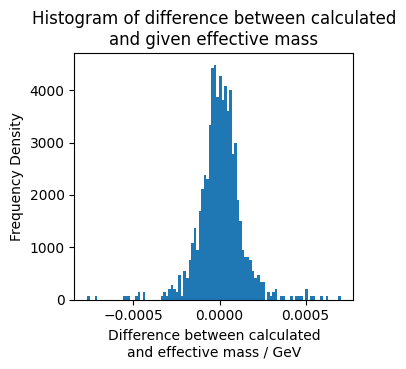

In [5]:
plt.figure(figsize=(3.6, 3.2))
plt.hist((transformed_small_data.get_column("calculated_effective_mass")
         - transformed_small_data.get_column("effective_mass")), bins=100, density=True)
plt.title("Histogram of difference between calculated\nand given effective mass")
plt.xlabel("Difference between calculated\nand effective mass / GeV")
plt.ylabel("Frequency Density")
plt.show()

The residuals from the graph above are within 0.001 GeV from the effective mass,
which means the effective mass data can be trusted, at least for the 1k dataset.

In [6]:
big_data = pl.read_csv("data/real-dimuon-4M.data", separator="\t", low_memory=True,
                            new_columns=["p_T1", "phi_1", "eta_1", "p_T2", "phi_2", "eta_2",
                                         "effective_mass"])

# clean data
big_data = big_data.remove(pl.col("p_T1") >= 1000)
big_data = big_data.remove(pl.col("p_T2") >= 1000)
# big_data = big_data.remove((pl.col("eta_1") < -2.7) | (pl.col("eta_1") > 2.7))


Plot a histogram of the variables given to try to get a sense of the data.

{'pseudorapidity': <Axes: label='pseudorapidity'>, 'azimuth': <Axes: label='azimuth'>, 'invariant mass': <Axes: label='invariant mass'>}


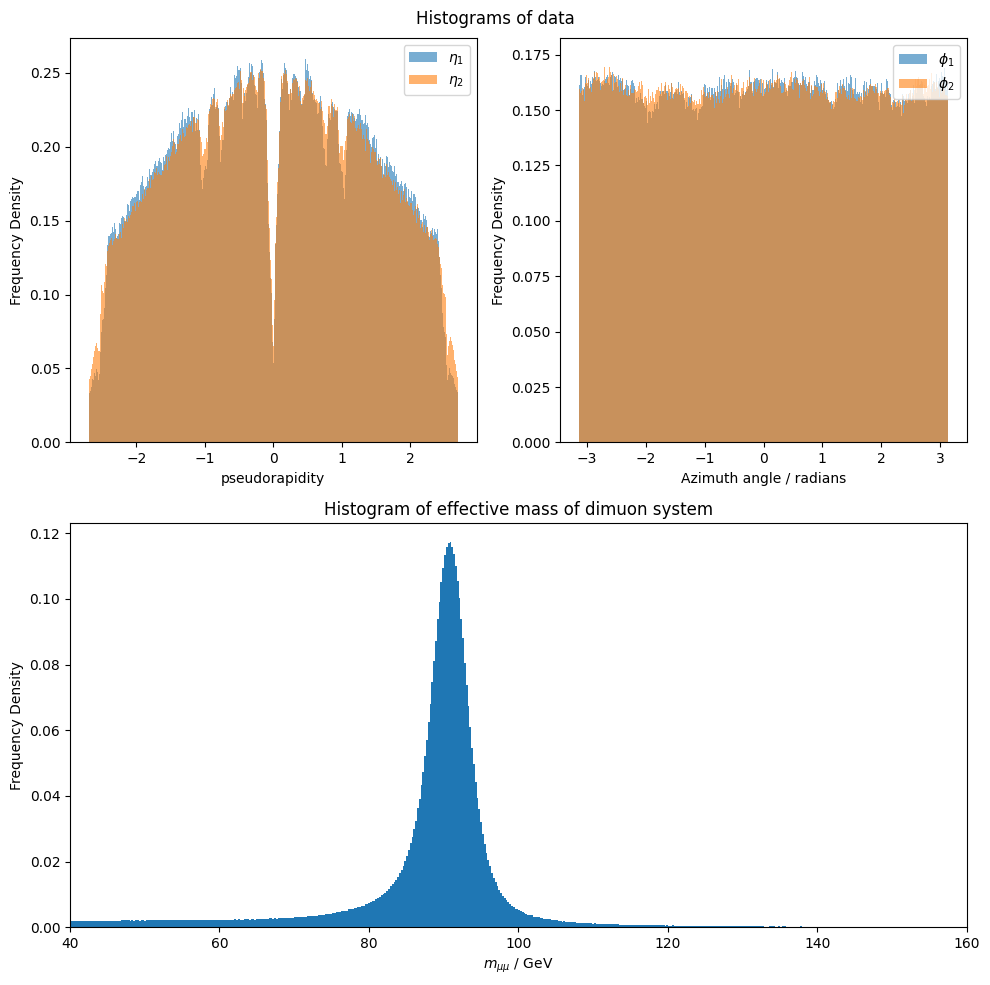

2.69999


In [7]:
fig = plt.figure(figsize=(10,10))
ax_dict = fig.subplot_mosaic([["pseudorapidity", "azimuth"],
                              ["invariant mass", "invariant mass"]],
)
print(ax_dict)

phi_plot = ax_dict["azimuth"]
eta_plot = ax_dict["pseudorapidity"]
m_pair_plot = ax_dict["invariant mass"]

m_pair_plot.hist(big_data.get_column("effective_mass"), bins=8000, density=True)
m_pair_plot.set_xlim(40, 160)
m_pair_plot.set_xlabel(r"$m_{\mu\mu}$ / GeV")
m_pair_plot.set_ylabel("Frequency Density")
m_pair_plot.set_title("Histogram of effective mass of dimuon system")

phi_plot.hist(big_data.get_column("phi_1"), alpha=0.6, label=r"$\phi_1$", bins=800, density=True)
phi_plot.hist(big_data.get_column("phi_2"), alpha=0.6, label=r"$\phi_2$", bins=800, density=True)
phi_plot.set_xlabel("Azimuth angle / radians")
phi_plot.set_ylabel("Frequency Density")
phi_plot.legend()

eta_plot.hist(big_data.get_column("eta_1"), alpha=0.6, label=r"$\eta_1$", bins=800, density=True)
eta_plot.hist(big_data.get_column("eta_2"), alpha=0.6, label=r"$\eta_2$", bins=800, density=True)
eta_plot.set_ylabel("Frequency Density")
eta_plot.set_xlabel("pseudorapidity")
eta_plot.legend()

fig.suptitle("Histograms of data")
fig.tight_layout()

plt.show()

# maximum pseudorapidity
print(big_data.get_column("eta_1").max())

2.7 is the maximum pseudorapidity value that is found using the muon detectors

In [8]:
print(big_data["eta_1"].describe()["value"][0])

3999989.0


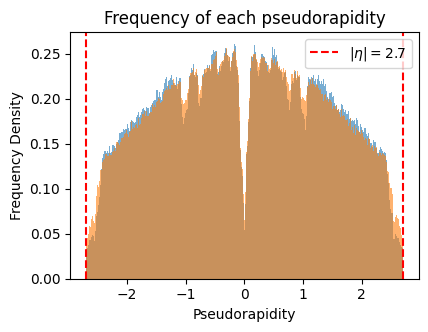

In [9]:
## Pseudorapidity plot
number_of_bins = 800
fig, ax = plt.subplots(figsize=(4.5, 3.2))
# use polars to sort the data into bins and then plot it
hist_bins_eta_1 = big_data["eta_1"].hist(bin_count=number_of_bins)
eta_1_count = big_data["eta_1"].describe()["value"][0]
# manipulate the data so that the stairs function can be used - stairs requires edges
length1 = (hist_bins_eta_1["breakpoint"][1:] - hist_bins_eta_1["breakpoint"][:-1]).mean()
density_eta_1 = hist_bins_eta_1["count"] / (eta_1_count * length1)
# ax.stairs(hist_bins_eta_1["count"],
#           pl.Series("_", [hist_bins_eta_1["breakpoint"][0] - length1]).append(hist_bins_eta_1["breakpoint"]),
#           fill=True, alpha=0.6, label=r"$\eta_1$")
ax.bar(hist_bins_eta_1["breakpoint"] - length1/2, density_eta_1, width=length1, alpha=0.6)
# ax.scatter(hist_bins_eta_1["breakpoint"] - length1/2, hist_bins_eta_1["count"], marker=".")

# same as above
eta_2_count = big_data["eta_2"].describe()["value"][0]
hist_bins_eta_2 = big_data["eta_2"].hist(bin_count=number_of_bins)
length2 = (hist_bins_eta_2["breakpoint"][1:] - hist_bins_eta_2["breakpoint"][:-1]).mean()
density_eta_2 = hist_bins_eta_2["count"] / (eta_2_count * length2)
# ax.stairs(hist_bins_eta_2["count"],
#           pl.Series("_", [hist_bins_eta_2["breakpoint"][0] - length2]).append(hist_bins_eta_2["breakpoint"]),
#           fill=True,
#           alpha=0.6,
#           label=r"$\eta_2$")
ax.bar(hist_bins_eta_1["breakpoint"] - length2/2, density_eta_2, width=length2, alpha=0.6)
ax.axvline(2.7, color="red", linestyle="--")
ax.axvline(-2.7, color="red", linestyle="--", label=r"$|\eta| = 2.7$")

# plot data
# ax.scatter(hist_bins_eta_2["breakpoint"] - length2/2, hist_bins_eta_2["count"], marker=".")
ax.set_title("Frequency of each pseudorapidity")
ax.set_xlabel("Pseudorapidity")
ax.set_ylabel("Frequency Density")
ax.legend()
plt.show()

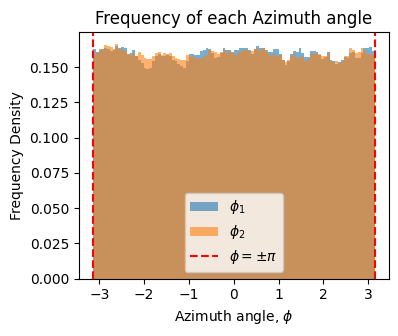

In [10]:
# now for azimuthal angle
number_of_bins = 100
fig, ax = plt.subplots(figsize=(4, 3.2))
# use polars to sort the data into bins and then plot it
hist_bins_phi_1 = big_data["phi_1"].hist(bin_count=number_of_bins)
number_phi_1 = big_data["phi_1"].describe()["value"][0]  # total count of phi_1
# manipulate the data so that the stairs function can be used - stairs requires edges
length1 = (hist_bins_phi_1["breakpoint"][1:] - hist_bins_phi_1["breakpoint"][:-1]).mean()
density_phi_1 = hist_bins_phi_1["count"] / (number_phi_1 * length1)
ax.stairs(density_phi_1,
          pl.Series("_", [hist_bins_phi_1["breakpoint"][0] - length1]).append(hist_bins_phi_1["breakpoint"]),
          fill=True, alpha=0.6, label=r"$\phi_1$")
# ax.bar(hist_bins_phi_1["breakpoint"] - length1/2, density_phi_1, length1, alpha=0.6, label=r"$\phi_1$")
# ax.scatter(hist_bins_phi_1["breakpoint"] - length1/2, hist_bins_phi_1["count"], marker=".")

# same as above
number_phi_2 = big_data["phi_2"].describe()["value"][0]  # total count of phi
hist_bins_phi_2 = big_data["phi_2"].hist(bin_count=number_of_bins)
length2 = (hist_bins_phi_2["breakpoint"][1:] - hist_bins_phi_2["breakpoint"][:-1]).mean()
density_phi_2 = hist_bins_phi_2["count"] / (number_phi_2 * length2)
ax.stairs(density_phi_2,
          pl.Series("_", [hist_bins_phi_2["breakpoint"][0] - length2]).append(hist_bins_phi_2["breakpoint"]),
          fill=True,
          alpha=0.6,
          label=r"$\phi_2$")
#ax.bar(hist_bins_phi_2["breakpoint"] - length2/2, density_phi_2, length2, alpha=0.6, label=r"$\phi_2$")


ax.axvline(np.pi, color="red", linestyle="--")
ax.axvline(-np.pi, color="red", linestyle="--", label=r"$\phi = \pm \pi$")

# plot data
# ax.scatter(hist_bins_eta_2["breakpoint"] - length2/2, hist_bins_eta_2["count"], marker=".")
ax.set_title(r"Frequency of each Azimuth angle")
ax.set_xlabel(r"Azimuth angle, $\phi$")
ax.set_ylabel("Frequency Density")
ax.legend()
plt.show()

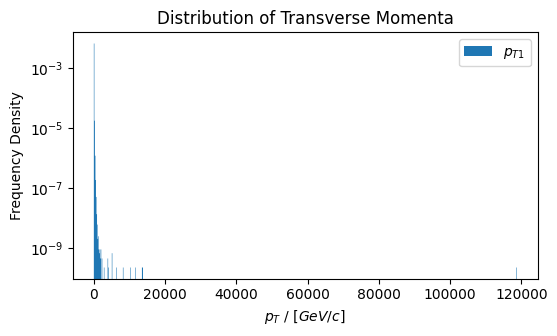

In [28]:
# transverse momentum
big_data = pl.read_csv("data/real-dimuon-29M.data", separator="\t", low_memory=True,
                            new_columns=["p_T1", "phi_1", "eta_1", "p_T2", "phi_2", "eta_2",
                                         "effective_mass"])
number_of_bins = 800
fig, ax = plt.subplots(figsize=(6, 3.2))
# use polars to sort the data into bins and then plot it
# remove unrealistic points
hist_bins_p_T1 = big_data["p_T1"].hist(bin_count=number_of_bins)
number_p_T1 = hist_bins_p_T1["count"].sum()
# manipulate the data so that the stairs function can be used - stairs requires edges
length1 = (hist_bins_p_T1["breakpoint"][1:] - hist_bins_p_T1["breakpoint"][:-1]).mean()
density_pT1 = hist_bins_p_T1["count"] / (number_p_T1 * length1)
ax.stairs(density_pT1,
          pl.Series("_", [hist_bins_p_T1["breakpoint"][0] - length1]).append(hist_bins_p_T1["breakpoint"]),
          fill=True, label=r"$p_{T1}$")
# ax.scatter(hist_bins_p_T1["breakpoint"] - length1/2, hist_bins_p_T1["count"], marker=".")

# # same as above
# hist_bins_p_T2 = big_data["p_T2"].hist(bin_count=number_of_bins)
# number_p_T2 = hist_bins_p_T2["count"].sum()
# length2 = (hist_bins_p_T2["breakpoint"][1:] - hist_bins_p_T2["breakpoint"][:-1]).mean()
# density_pT2 = hist_bins_p_T2["count"] / (number_p_T2 * length2)
# ax.stairs(density_pT2,
#           pl.Series("_", [hist_bins_p_T2["breakpoint"][0] - length2]).append(hist_bins_p_T2["breakpoint"]),
#           fill=True,
#           alpha=0.6,
#           label=r"$p_{T2}$")
# ax.scatter(hist_bins_p_T2["breakpoint"] - length2/2, hist_bins_p_T2["count"], marker=".")

# ax.axvline(7, color="red", linestyle="--", label=r"$p_T = 7$ $GeV/c$")
# ax.axvline(25, color="purple", linestyle="--", label=r"$p_T = 25$ $GeV/c$")

# plot data
ax.set_title("Distribution of Transverse Momenta")
ax.set_xlabel("$p_T$ / [$GeV/c$]")
ax.set_ylabel("Frequency Density")
ax.set_yscale("log")
ax.legend()
plt.show()


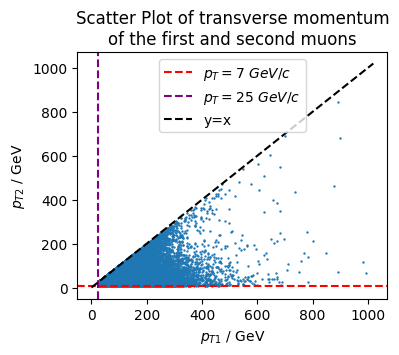

In [12]:
plt.figure(figsize=(4, 3.2))
plt.scatter(big_data["p_T1"], big_data['p_T2'], marker=".", s=2)
plt.axhline(7, color="red", label=r"$p_T = 7$ $GeV/c$", linestyle="--")
plt.axvline(25, color="purple", label=r"$p_T = 25$ $GeV/c$", linestyle="--")
x_coords = np.linspace(0, 1020)
plt.plot(x_coords, x_coords, color="k", linestyle="--", label="y=x")
plt.title("Scatter Plot of transverse momentum\nof the first and second muons")
plt.xlabel(r"$p_{T1}$ / GeV")
plt.ylabel(r"$p_{T2}$ / GeV")
plt.legend(loc="upper center")
plt.show()

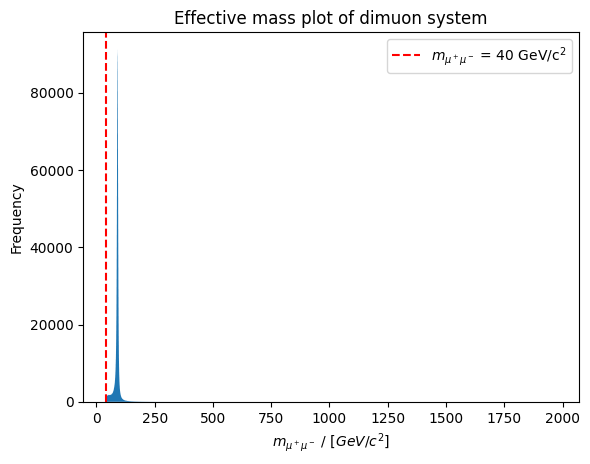

In [13]:
# transverse momentum
number_of_bins = 10000
fig, ax = plt.subplots()
# use polars to sort the data into bins and then plot it
# remove unrealistic points
hist_bins_effective_mass = big_data["effective_mass"].hist(bin_count=number_of_bins)
# manipulate the data so that the stairs function can be used - stairs requires edges
length1 = (hist_bins_effective_mass["breakpoint"][1:] - hist_bins_effective_mass["breakpoint"][:-1]).mean()
ax.stairs(hist_bins_effective_mass["count"],
          pl.Series("_", [hist_bins_effective_mass["breakpoint"][0] - length1]).append(hist_bins_effective_mass["breakpoint"]),
          fill=True,)
# ax.scatter(hist_bins_effective_mass["breakpoint"] - length1/2, hist_bins_effective_mass["count"], marker=".")

ax.axvline(40, color="red", linestyle="--", label=r"$m_{\mu^+\mu^-}$ = 40 GeV/c$^2$")


ax.set_title("Effective mass plot of dimuon system")
ax.set_xlabel(r"$m_{\mu^+\mu^-}$ / [$GeV/c^2$]")
ax.set_ylabel("Frequency")
# ax.set_xlim(0, 200)
ax.legend()
plt.show()

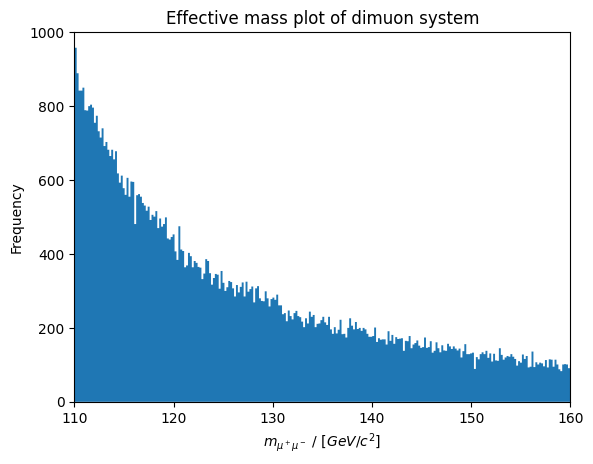

In [14]:
number_of_bins = 10000
fig, ax = plt.subplots()
# use polars to sort the data into bins and then plot it
# remove unrealistic points
hist_bins_effective_mass = big_data["effective_mass"].hist(bin_count=number_of_bins)
# manipulate the data so that the stairs function can be used - stairs requires edges
length1 = (hist_bins_effective_mass["breakpoint"][1:] - hist_bins_effective_mass["breakpoint"][:-1]).mean()
ax.stairs(hist_bins_effective_mass["count"],
          pl.Series("_", [hist_bins_effective_mass["breakpoint"][0] - length1]).append(hist_bins_effective_mass["breakpoint"]),
          fill=True,)
# ax.scatter(hist_bins_effective_mass["breakpoint"] - length1/2, hist_bins_effective_mass["count"], marker=".")

# ax.axvline(40, color="red", linestyle="--", label=r"$m_{\mu^+\mu^-}$ = 40 GeV/c$^2$")


ax.set_title("Effective mass plot of dimuon system")
ax.set_xlabel(r"$m_{\mu^+\mu^-}$ / [$GeV/c^2$]")
ax.set_ylabel("Frequency")
ax.set_xlim(110, 160)
ax.set_ylim(0, 1000)
# ax.legend()
plt.show()

In [15]:
transformed_big_data = perform_transformation(big_data)

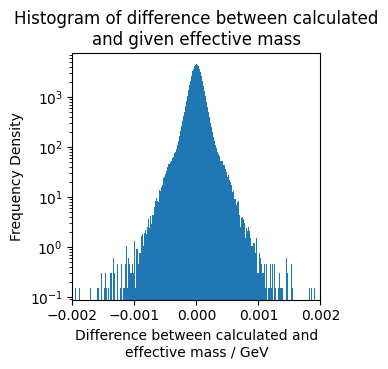

In [16]:
plt.figure(figsize=(3.2, 3.2))
plt.yscale("log")
plt.hist((transformed_big_data["calculated_effective_mass"]
         - transformed_big_data["effective_mass"]), bins=8000, density=True)
plt.title("Histogram of difference between calculated\nand given effective mass")
plt.xlabel("Difference between calculated and\neffective mass / GeV")
plt.ylabel("Frequency Density")
plt.xlim(-0.002, 0.002)
plt.show()

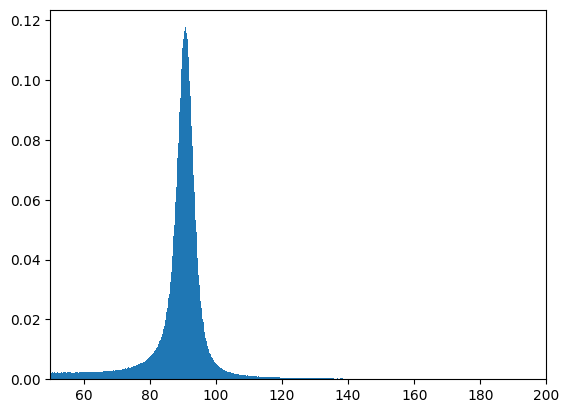

In [17]:
plt.hist(transformed_big_data.get_column("calculated_effective_mass"), bins=10000, density=True)
plt.xlim(50, 200)
# plt.ylim(80000, 100000)
# plt.ylim(0, 1000)
plt.show()

In [18]:
simulated_higgs2mumu = np.loadtxt("data/simulated_higgs2mumu.data")  # np.loadtxt is used here
                                                                     # because the simulated data uses both
                                                                     # spaces and tabs as separators, which
                                                                     # the polars.read_csv function cannot
                                                                     # deal with
simulated_higgs2mumu = pl.DataFrame(simulated_higgs2mumu, schema=
                                    ["p_T1", "phi_1", "eta_1", "p_T2", "phi_2", "eta_2", "effective_mass"])

In [19]:
simulated_higgs2mumu = perform_transformation(simulated_higgs2mumu)

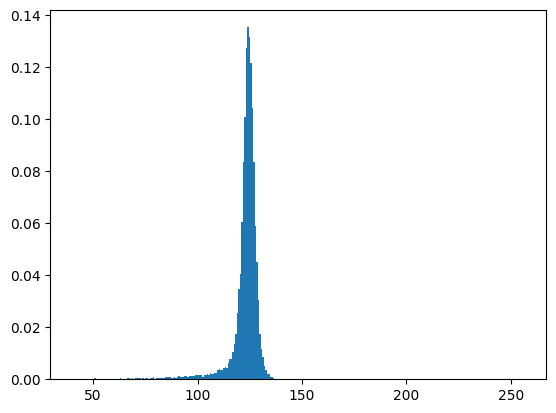

In [20]:
plt.hist(simulated_higgs2mumu.get_column("effective_mass"), bins=300, density=True)
plt.show()